# Deep Learning for Pharmacy Sales Prediction

## Objective
Build a deep learning model to predict pharmacy sales using multiple datasets.

## Data Sources
- Patient Data
- Prescription Data
- Pharmacy Data
- Weather Data
- Population Data
- Outbreak Data

## Target
Predict: `sales / demand`

## Approach
- Merge datasets
- Feature selection
- Deep Learning Regression Model

## Imports

In [1]:
import pandas as pd
import numpy as np

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

## Load Data

In [2]:
df = pd.read_csv("../data/encoded/pharmacy_encoded.csv")

df.head()

,date,pharmacy_id,medicine_name,units_sold,price_per_unit,total_sales,prescriptions_count,temperature,humidity,rainfall,...,city_Nagpur,city_Patna,city_Pune,city_Surat,city_Vadodara,medicine_category_Antidiabetic,medicine_category_Antihypertensive,medicine_category_Antiviral,medicine_category_Painkiller,medicine_category_Vitamin
0,2020-01-01,PHARM0031,14,29,47,1363,9,39.2,100.0,1.5,...,False,False,False,False,False,False,False,False,True,False
1,2020-01-01,PHARM0661,0,29,42,1218,13,18.3,56.0,10.7,...,False,False,False,False,False,True,False,False,False,False
2,2020-01-01,PHARM0228,19,35,18,630,8,22.0,72.2,5.5,...,False,False,False,False,False,False,False,True,False,False
3,2020-01-01,PHARM0936,11,25,43,1075,9,22.7,100.0,3.6,...,False,False,False,False,False,False,False,False,False,False
4,2020-01-01,PHARM0413,17,28,78,2184,17,24.9,72.8,11.8,...,False,True,False,False,False,False,False,True,False,False


## Define Target

In [3]:
y = df["units_sold"]
X = df.drop(columns=[
    "units_sold",
    "date",
    "pharmacy_id",
    "medicine_name"
])

## Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Scaling

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Building Deep Learning Model

In [6]:
model = tf.keras.Sequential([

    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dense(64, activation='relu'),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(32, activation='relu'),

    tf.keras.layers.Dense(1)   # regression output
])

/Users/ujjwal/.pyenv/versions/3.11.9/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile Model

In [8]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,233 (59.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 256 (1.00 KB)

## Early Stopping


In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## Train Model

In [10]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop]
)

Epoch 1/30
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 25s 946us/step - loss: 7.1730 - mae: 1.7416 - val_loss: 12.0456 - val_mae: 2.7661
Epoch 2/30
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 23s 934us/step - loss: 1.0127 - mae: 0.7515 - val_loss: 4.2213 - val_mae: 1.2537
Epoch 3/30
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 23s 934us/step - loss: 0.5436 - mae: 0.5513 - val_loss: 2.6676 - val_mae: 1.0444
Epoch 4/30
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 23s 932us/step - loss: 0.4335 - mae: 0.4898 - val_loss: 2.5445 - val_mae: 0.9445
Epoch 5/30
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 24s 945us/step - loss: 0.3765 - mae: 0.4543 - val_loss: 2.0528 - val_mae: 0.8515
Epoch 6/30
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 24s 949us/step - loss: 0.3502 - mae: 0.4348 - val_loss: 1.4500 - val_mae: 0.7208
Epoch 7/30
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 24s 940us/step - loss: 0.3186 - mae: 0.4123 - val_loss: 1.2117 - val_mae: 0.6340
Epoch 8/30
25000/25000 ━━━━━━━━━━━━━━━━━━━━ 25s 984us/step - loss: 0.2956 - mae: 0.3945 - val_loss: 0.9414 - val_mae: 0.6173

## Plot

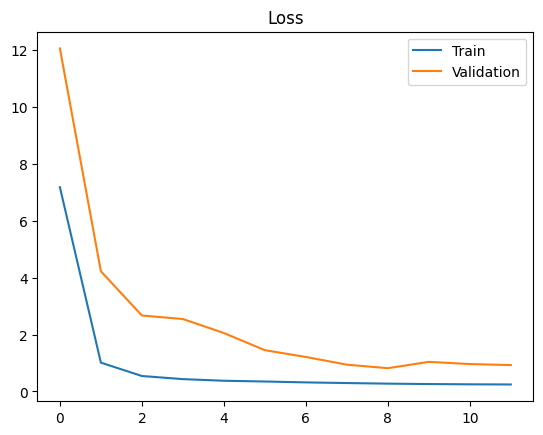

In [11]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train","Validation"])
plt.show()

In [12]:
from sklearn.metrics import r2_score

pred = model.predict(X_test_scaled)

print("R2 Score:", r2_score(y_test, pred))

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 3s 444us/step
R2 Score: 0.9787904024124146


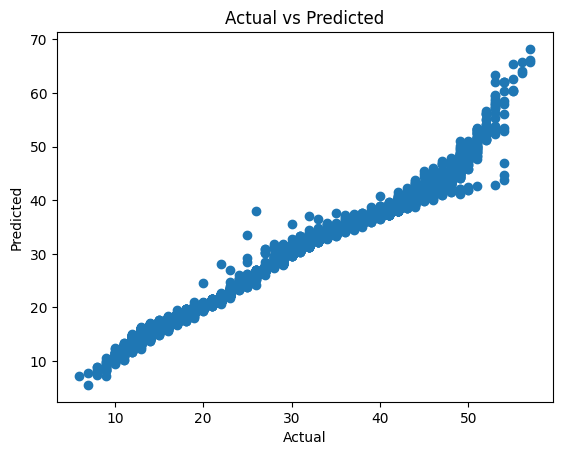

In [13]:
plt.scatter(y_test, pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

## Evaluate

In [14]:
loss, mae = model.evaluate(X_test_scaled, y_test)

print("MAE:", mae)

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 3s 553us/step - loss: 0.8180 - mae: 0.4925
MAE: 0.4925386607646942


## Save Model

In [ ]:
model.save("../models/pharmacy_sales_dl_model.h5")

import joblib
joblib.dump(scaler, "../models/sales_scaler.pkl")

)

['../models/sales_scaler.pkl']

## Prediction Function

In [16]:
sample = X_test.iloc[0:1]

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

print("Predicted Sales:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Predicted Sales: 30.093546


## Conclusion

- Deep learning regression model built successfully
- Captures complex relationships across datasets
- Useful for forecasting pharmacy demand
